In [1]:
import sys
import pandas as pd
import numpy as np
from multiprocessing import Pool
from plotnine import *
import plotnine as plt

PATH = "/home/jmurga/mkt/202004" 
sys.path.insert(0, PATH + '/scripts/src/')  
from pyAmkt import *
from slimParser import *

Create the output directory. You should change the directory tree if you clone the github repo

In [ ]:
!mkdir -p /home/jmurga/mkt/202004/rawData/simulations /home/jmurga/mkt/202004/rawData/summStat /home/jmurga/mkt/202004/rawData/dofe/noDemog

# No demography simulations

## Solving values to simulate with Analytical.jl

In [ ]:
!which julia

Add the proper packages to your Julia session

In [ ]:
!julia -e 'using Pkg;Pkg.add("CSV");Pkg.add("DataFrames");Pkg.add(PackageSpec(path="https://github.com/jmurga/Analytical.jl"))'

In [ ]:
!julia /home/jmurga/mkt/202004/scripts/src/simTable.jl 500 200000 bgsTable

In [3]:
simTable = pd.read_csv(PATH + "/rawData/simulations/bgsTable.tsv", sep='\t')
simTable['path'] = simTable.apply(lambda row: "/home/jmurga/mkt/202004/rawData/simulations/noDemog/ne500/noDemog_" + str(row['alpha']) + "_" + str(row['alphaW']) + "_" + str(np.round(row['B'],4)),axis=1)
simTable['analysis']= 'noDemog'

I test two cases in the notebook case I select one row from simTable

## Running SLiM

Generating replicates and folders. It depends on GNU parallel tool and SLiM

In [3]:
nSamples=500
binnedSfs=(nSamples*2)-1

In [ ]:
runSlim(recipe="/home/jmurga/mkt/202004/scripts/slimRecipes/bgs.slim",simTable=tmpSim,pSize=500,codingLength=2000,strongStrength=500,weaklyStrength=10,bins=binnedSfs,replicas=[1,50000],threads=8,slimPath="/home/jmurga/.conda/envs/abcmk/bin/slim",parallelPath="/home/jmurga/.conda/envs/abcmk/bin/parallel")

In [ ]:
runSlim(recipe="/home/jmurga/mkt/202004/scripts/slimRecipes/bgs.slim",simTable=tmpSim.tail(1),pSize=1000,codingLength=10000,strongStrength=500,weaklyStrength=10,bins=binnedSfs,replicas=[1,10000],threads=5,slimPath="/home/jmurga/.conda/envs/abcmk/bin/slim",parallelPath="/home/jmurga/.conda/envs/abcmk/bin/parallel")

## Processing simulated data

### All simulations

In [56]:
simTable=simTable.tail(3).head(1);simTable

,bgsThetaF,pposL,pposH,alphaW,alpha,estimation,B,path
9,8.220000e-10,0.003896,0.000397,0.1,0.4,0.40147,0.999,/home/jmurga/mkt/202004/rawData/simulations/no...


In [60]:
for index,row in simTable.iterrows():
    print(row.path)
    parsePolDiv(row.path,500)

/home/jmurga/mkt/202004/rawData/simulations/noDemog/noDemog_0.4_0.1_0.999


100%|██████████| 50000/50000 [01:27<00:00, 572.92it/s]


In [9]:
df,dfAlpha = saveSimulatedAlphas(simTable,h=0.7);dfAlpha
df = df.round(3);df

,trueAlpha,asymp_nopos,asymp,analyticalEstimation,path,analysis
0,0.194,0.139,0.113,0.257,noDemog_0.4_0.1_0.2,noDemog
0,0.178,0.138,0.087,0.231,noDemog_0.4_0.2_0.2,noDemog
0,0.161,0.104,0.032,0.203,noDemog_0.4_0.3_0.2,noDemog
0,0.273,0.229,0.198,0.313,noDemog_0.4_0.1_0.4,noDemog
0,0.253,0.216,0.152,0.296,noDemog_0.4_0.2_0.4,noDemog
0,0.238,0.187,0.094,0.277,noDemog_0.4_0.3_0.4,noDemog
0,0.369,0.335,0.300,0.379,noDemog_0.4_0.1_0.8,noDemog
0,0.352,0.321,0.243,0.374,noDemog_0.4_0.2_0.8,noDemog
0,0.335,0.303,0.191,0.370,noDemog_0.4_0.3_0.8,noDemog
0,0.401,0.373,0.335,0.401,noDemog_0.4_0.1_0.999,noDemog


In [5]:
df.to_csv(PATH + '/results/simulations/alphasSimulations/simulatedAlphas.tsv',index=False,sep='\t',header=True)

In [6]:
dfAlpha.to_csv(PATH + '/results/simulations/alphasSimulations/simulatedToPlotAll.tsv',index=False,sep='\t',header=True)

In [73]:
dfAlpha['path'] = pd.Categorical(dfAlpha['path'], ["noDemog_0.4_0.1_0.2","noDemog_0.4_0.2_0.2","noDemog_0.4_0.3_0.2","noDemog_0.4_0.1_0.4","noDemog_0.4_0.2_0.4","noDemog_0.4_0.3_0.4","noDemog_0.4_0.1_0.8","noDemog_0.4_0.2_0.8","noDemog_0.4_0.3_0.8","noDemog_0.4_0.1_0.999","noDemog_0.4_0.2_0.999","noDemog_0.4_0.3_0.999"])

/home/jmurga/.conda/lib/python3.8/site-packages/plotnine/geoms/geom_path.py:75: PlotnineWarning: geom_path: Removed 1 rows containing missing values.


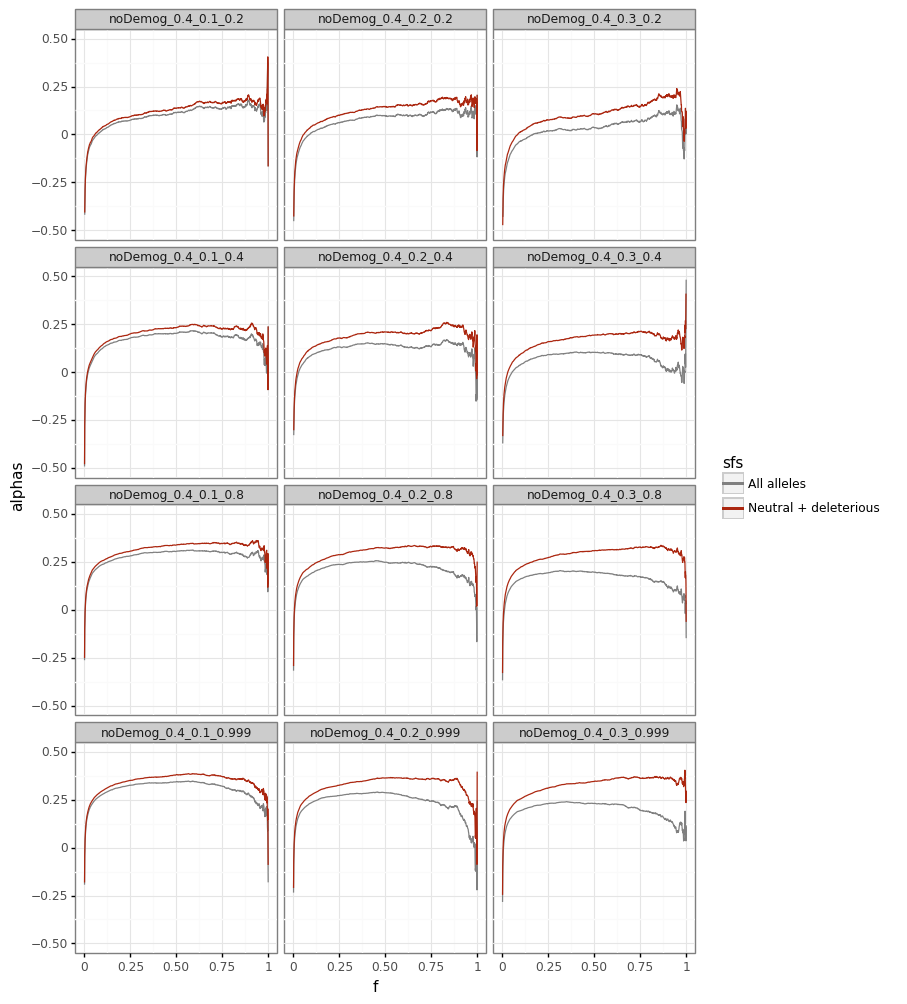

<ggplot: (8750963271277)>

In [74]:
plt.options.figure_size=(8,12)
p = (ggplot(dfAlpha, aes(x='f',y='alphas',color='sfs')) + geom_line() + facet_wrap('~path',ncol=3) + ylim(-0.5,0.5)) + scale_color_manual({'All alleles':'gray',"Neutral + deleterious":'#ab2710'}) + theme_bw();p

In [43]:
ggsave(p,"/home/jmurga/mkt/202004/results/simulations/alphasSimulations/simulatedAlphas.jpg",dpi=600)

/home/jmurga/.conda/lib/python3.8/site-packages/plotnine/ggplot.py:727: PlotnineWarning: Saving 8 x 12 in image.
/home/jmurga/.conda/lib/python3.8/site-packages/plotnine/ggplot.py:730: PlotnineWarning: Filename: /home/jmurga/mkt/202004/results/simulations/alphasSimulations/simulatedAlphas.jpg
/home/jmurga/.conda/lib/python3.8/site-packages/plotnine/geoms/geom_path.py:75: PlotnineWarning: geom_path: Removed 1 rows containing missing values.


In [75]:
df,dfAlpha = saveSimulatedAlphas(simTable,bins=100);dfAlpha

/home/jmurga/mkt/202004/rawData/simulations/noDemog/ne500/noDemog_0.4_0.1_0.2
/home/jmurga/mkt/202004/rawData/simulations/noDemog/ne500/noDemog_0.4_0.2_0.2
/home/jmurga/mkt/202004/rawData/simulations/noDemog/ne500/noDemog_0.4_0.3_0.2
/home/jmurga/mkt/202004/rawData/simulations/noDemog/ne500/noDemog_0.4_0.1_0.4
/home/jmurga/mkt/202004/rawData/simulations/noDemog/ne500/noDemog_0.4_0.2_0.4
/home/jmurga/mkt/202004/rawData/simulations/noDemog/ne500/noDemog_0.4_0.3_0.4
/home/jmurga/mkt/202004/rawData/simulations/noDemog/ne500/noDemog_0.4_0.1_0.8
/home/jmurga/mkt/202004/rawData/simulations/noDemog/ne500/noDemog_0.4_0.2_0.8
/home/jmurga/mkt/202004/rawData/simulations/noDemog/ne500/noDemog_0.4_0.3_0.8
/home/jmurga/mkt/202004/rawData/simulations/noDemog/ne500/noDemog_0.4_0.1_0.999
/home/jmurga/mkt/202004/rawData/simulations/noDemog/ne500/noDemog_0.4_0.2_0.999
/home/jmurga/mkt/202004/rawData/simulations/noDemog/ne500/noDemog_0.4_0.3_0.999


,f,alphas,B,alphaW,sfs,path,analysis
0,0.01,-0.417901,0.200,0.1,Neutral + deleterious,noDemog_0.4_0.1_0.2,noDemog
1,0.02,-0.187314,0.200,0.1,Neutral + deleterious,noDemog_0.4_0.1_0.2,noDemog
2,0.03,-0.129683,0.200,0.1,Neutral + deleterious,noDemog_0.4_0.1_0.2,noDemog
3,0.04,-0.093737,0.200,0.1,Neutral + deleterious,noDemog_0.4_0.1_0.2,noDemog
4,0.05,-0.070078,0.200,0.1,Neutral + deleterious,noDemog_0.4_0.1_0.2,noDemog
...,...,...,...,...,...,...,...
194,1.95,0.112654,0.999,0.3,All alleles,noDemog_0.4_0.3_0.999,noDemog
195,1.96,0.085346,0.999,0.3,All alleles,noDemog_0.4_0.3_0.999,noDemog
196,1.97,0.044968,0.999,0.3,All alleles,noDemog_0.4_0.3_0.999,noDemog
197,1.98,0.130579,0.999,0.3,All alleles,noDemog_0.4_0.3_0.999,noDemog


In [76]:
dfAlpha['path'] = pd.Categorical(dfAlpha['path'], ["noDemog_0.4_0.1_0.2","noDemog_0.4_0.2_0.2","noDemog_0.4_0.3_0.2","noDemog_0.4_0.1_0.4","noDemog_0.4_0.2_0.4","noDemog_0.4_0.3_0.4","noDemog_0.4_0.1_0.8","noDemog_0.4_0.2_0.8","noDemog_0.4_0.3_0.8","noDemog_0.4_0.1_0.999","noDemog_0.4_0.2_0.999","noDemog_0.4_0.3_0.999"])

In [33]:
dfAlpha.to_csv(PATH + '/results/simulations/alphasSimulations/simulatedToPlotReduced.tsv',index=False,sep='\t',header=True)

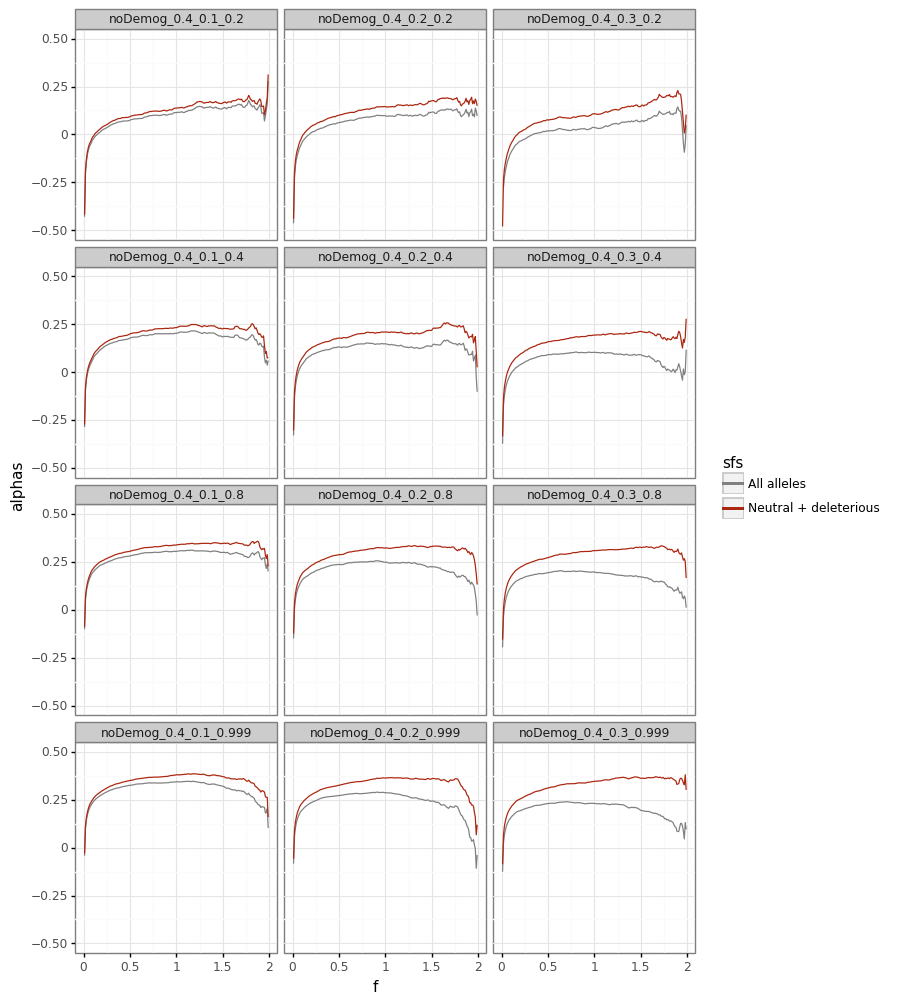

<ggplot: (8750963274409)>

In [77]:
plt.options.figure_size=(8,12)
p = (ggplot(dfAlpha, aes(x='f',y='alphas',color='sfs')) + geom_line() + facet_wrap('~path',ncol=3) + ylim(-0.5,0.5)) + scale_color_manual({'All alleles':'gray',"Neutral + deleterious":'#ab2710'}) + theme_bw();p

In [35]:
ggsave(p,"/home/jmurga/mkt/202004/results/simulations/alphasSimulations/simulatedAlphasReduced.jpg",dpi=300)

/home/jmurga/.conda/lib/python3.8/site-packages/plotnine/ggplot.py:727: PlotnineWarning: Saving 8 x 12 in image.
/home/jmurga/.conda/lib/python3.8/site-packages/plotnine/ggplot.py:730: PlotnineWarning: Filename: /home/jmurga/mkt/202004/results/simulations/alphasSimulations/simulatedAlphasReduced.jpg
/home/jmurga/.conda/lib/python3.8/site-packages/plotnine/geoms/geom_path.py:75: PlotnineWarning: geom_path: Removed 1 rows containing missing values.


### Convert SFS to DOFE and bootstrap

In [7]:
for index, row in simTable.iterrows():
    print(row.path)
    parseBootstrapPolDiv(path=row.path,N=500,output="/home/jmurga/mkt/202004/rawData/noDemog1000/",sample=50000,replicas=100,dofe=False,bins=500,nthreads=8)

'/home/jmurga/mkt/202004/rawData/simulations/noDemog/ne500/noDemog_0.4_0.1_0.2'
'/home/jmurga/mkt/202004/rawData/simulations/noDemog/ne500/noDemog_0.4_0.2_0.2'
'/home/jmurga/mkt/202004/rawData/simulations/noDemog/ne500/noDemog_0.4_0.3_0.2'
'/home/jmurga/mkt/202004/rawData/simulations/noDemog/ne500/noDemog_0.4_0.1_0.4'
'/home/jmurga/mkt/202004/rawData/simulations/noDemog/ne500/noDemog_0.4_0.2_0.4'
'/home/jmurga/mkt/202004/rawData/simulations/noDemog/ne500/noDemog_0.4_0.3_0.4'
'/home/jmurga/mkt/202004/rawData/simulations/noDemog/ne500/noDemog_0.4_0.1_0.8'
'/home/jmurga/mkt/202004/rawData/simulations/noDemog/ne500/noDemog_0.4_0.2_0.8'
'/home/jmurga/mkt/202004/rawData/simulations/noDemog/ne500/noDemog_0.4_0.3_0.8'
'/home/jmurga/mkt/202004/rawData/simulations/noDemog/ne500/noDemog_0.4_0.1_0.999'
'/home/jmurga/mkt/202004/rawData/simulations/noDemog/ne500/noDemog_0.4_0.2_0.999'
'/home/jmurga/mkt/202004/rawData/simulations/noDemog/ne500/noDemog_0.4_0.3_0.999'


# Tennesen model

## Solving values to simulate with Analytical.jl

In [ ]:
!which julia

In [ ]:
!julia /home/jmurga/mkt/202004/scripts/src/simTable.jl 7310 100000 tennensen.tsv

## Solving values to simulate with Analytical.jl

In [60]:
simTable = pd.read_csv(PATH + "/rawData/simulations/tennesen.tsv", sep='\t')
simTable['path'] = simTable.apply(lambda row: "/home/jmurga/mkt/202004/rawData/simulations/isolationRescaled/isolation_" + str(row['alpha']) + "_" + str(row['alphaW']) + "_" + str(np.round(row['B'],4)),axis=1)
simTable['analysis'] = 'isolation'

To test just one case I select one row from simTable

In [7]:
tmpSim = simTable.tail(1)

## Running SLiM

Generating replicates and folders. It depends on GNU parallel tool and SLiM

In [6]:
nSamples=661
binnedSfs = (nSamples * 2) - 1

In [ ]:
runSlim(recipe="/home/jmurga/mkt/202004/scripts/slimRecipes/tennesen.slim",simTable=tmpSim,pSize=500,codingLength=2000,strongStrength=500,weaklyStrength=10,sSize=nSamples,replicas=[1,50000],threads=7,slimPath="/home/jmurga/.conda/envs/abcmk/bin/slim",parallelPath="/home/jmurga/.conda/envs/abcmk/bin/parallel")

## Processing simulated data

In [ ]:
for index,row in simTable.iterrows():
    parsePolDiv(row.path,661,7)

In [63]:
df,dfAlpha = saveSimulatedAlphas(table=simTable);dfAlpha['B'] = round(dfAlpha['B'],3);

/home/jmurga/mkt/202004/rawData/simulations/isolationRescaled/isolation_0.4_0.1_0.2
/home/jmurga/mkt/202004/rawData/simulations/isolationRescaled/isolation_0.4_0.2_0.2
/home/jmurga/mkt/202004/rawData/simulations/isolationRescaled/isolation_0.4_0.3_0.2
/home/jmurga/mkt/202004/rawData/simulations/isolationRescaled/isolation_0.4_0.1_0.4
/home/jmurga/mkt/202004/rawData/simulations/isolationRescaled/isolation_0.4_0.2_0.4
/home/jmurga/mkt/202004/rawData/simulations/isolationRescaled/isolation_0.4_0.3_0.4
/home/jmurga/mkt/202004/rawData/simulations/isolationRescaled/isolation_0.4_0.1_0.8
/home/jmurga/mkt/202004/rawData/simulations/isolationRescaled/isolation_0.4_0.2_0.8
/home/jmurga/mkt/202004/rawData/simulations/isolationRescaled/isolation_0.4_0.3_0.8
/home/jmurga/mkt/202004/rawData/simulations/isolationRescaled/isolation_0.4_0.1_0.999
/home/jmurga/mkt/202004/rawData/simulations/isolationRescaled/isolation_0.4_0.2_0.999
/home/jmurga/mkt/202004/rawData/simulations/isolationRescaled/isolation_

In [54]:
df

,trueAlpha,asymp_nopos,asymp,analyticalEstimation,path,analysis
0,0.208582,0.159860,0.120182,0.25688,isolation_0.4_0.1_0.2,isolation
0,0.191582,0.183590,0.105001,0.23086,isolation_0.4_0.2_0.2,isolation
0,0.177178,0.164698,0.042776,0.20285,isolation_0.4_0.3_0.2,isolation
0,0.251018,0.158935,NaN,0.31311,isolation_0.4_0.1_0.4,isolation
0,0.265350,0.245319,0.148530,0.29542,isolation_0.4_0.2_0.4,isolation
0,0.249088,0.248128,0.095686,0.27673,isolation_0.4_0.3_0.4,isolation
0,0.359544,0.320086,0.263485,0.37851,isolation_0.4_0.1_0.8,isolation
0,0.350316,0.321598,NaN,0.37433,isolation_0.4_0.2_0.8,isolation
0,0.341459,0.323675,NaN,0.37008,isolation_0.4_0.3_0.8,isolation
0,0.389288,0.357205,0.297101,0.40134,isolation_0.4_0.1_0.999,isolation


In [64]:
dfAlpha['group'] = dfAlpha.path + ": " + dfAlpha.sfs
dfAlpha['path']  = pd.Categorical(dfAlpha.path, categories=pd.unique(dfAlpha.path))

In [65]:
plt.options.figure_size=(10,7)
p = (ggplot(dfAlpha, aes(x='f',y='alphas',color='sfs')) + geom_line() + facet_wrap('~path',ncol=3,scales='free_x') + ylim(-0.5,0.5) + scale_color_manual({'All alleles':'gray',"Neutral + deleterious":'#ab2710'}) + theme_bw() + theme(legend_position='bottom'))
ggsave(p,filename=PATH + "/results/simulations/slim/isolation/isolationRecaledSimulations.svg")

/home/jmurga/.conda/lib/python3.8/site-packages/plotnine/ggplot.py:727: PlotnineWarning: Saving 10 x 7 in image.
/home/jmurga/.conda/lib/python3.8/site-packages/plotnine/ggplot.py:730: PlotnineWarning: Filename: /home/jmurga/mkt/202004/results/simulations/slim/isolation/isolationRecaledSimulations.svg
/home/jmurga/.conda/lib/python3.8/site-packages/plotnine/facets/facet.py:555: PlotnineWarning: If you need more space for the y-axis tick text use ... + theme(subplots_adjust={'hspace': 0.25}). Choose an appropriate value for 'hspace'
/home/jmurga/.conda/lib/python3.8/site-packages/plotnine/geoms/geom_path.py:75: PlotnineWarning: geom_path: Removed 1 rows containing missing values.


/home/jmurga/.conda/lib/python3.8/site-packages/plotnine/facets/facet.py:555: PlotnineWarning: If you need more space for the y-axis tick text use ... + theme(subplots_adjust={'hspace': 0.25}). Choose an appropriate value for 'hspace'
/home/jmurga/.conda/lib/python3.8/site-packages/plotnine/geoms/geom_path.py:75: PlotnineWarning: geom_path: Removed 1 rows containing missing values.


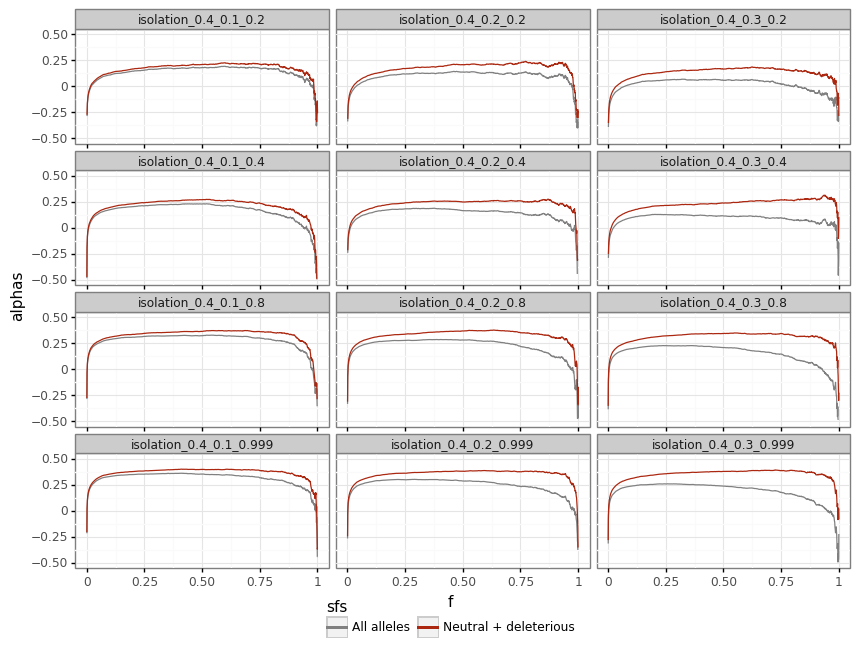

<ggplot: (8750999579118)>

In [66]:
p

# Tennesen two epochs model

We have modified the tennesen model to perform the isolation model without the final exponential at African population. We move to a two epoch model: a stable population experimented an instantaneous change N generations ago.

## Running SLiM

## Processig simulated data

In [2]:
simTable = pd.read_csv(PATH + "/rawData/simulations/tennesen.tsv", sep='\t')
simTable['path'] = simTable.apply(lambda row: "/home/jmurga/mkt/202004/rawData/simulations/twoepochs/twoepochs_" + str(row['alpha']) + "_" + str(row['alphaW']) + "_" + str(np.round(row['B'],4)),axis=1)
simTable['analysis'] = 'twoepochs'

## Processing simulated data

Pooling the simulations into one SFS and divergence file

In [3]:
for index,row in simTable.iterrows():
    print(row.path)
    parsePolDiv(row.path,661,8)

/home/jmurga/mkt/202004/rawData/simulations/twoepochs/twoepochs_0.4_0.1_0.2
/home/jmurga/mkt/202004/rawData/simulations/twoepochs/twoepochs_0.4_0.2_0.2
/home/jmurga/mkt/202004/rawData/simulations/twoepochs/twoepochs_0.4_0.3_0.2
/home/jmurga/mkt/202004/rawData/simulations/twoepochs/twoepochs_0.4_0.1_0.4
/home/jmurga/mkt/202004/rawData/simulations/twoepochs/twoepochs_0.4_0.2_0.4
/home/jmurga/mkt/202004/rawData/simulations/twoepochs/twoepochs_0.4_0.3_0.4
/home/jmurga/mkt/202004/rawData/simulations/twoepochs/twoepochs_0.4_0.1_0.8
/home/jmurga/mkt/202004/rawData/simulations/twoepochs/twoepochs_0.4_0.2_0.8
/home/jmurga/mkt/202004/rawData/simulations/twoepochs/twoepochs_0.4_0.3_0.8
/home/jmurga/mkt/202004/rawData/simulations/twoepochs/twoepochs_0.4_0.1_0.999
/home/jmurga/mkt/202004/rawData/simulations/twoepochs/twoepochs_0.4_0.2_0.999
/home/jmurga/mkt/202004/rawData/simulations/twoepochs/twoepochs_0.4_0.3_0.999


Original aMK analysis. We have performed the analysis accounting or not for weakly beneficial at the SFS

In [11]:
df,dfAlpha = saveSimulatedAlphas(table=simTable,cumulative=True,h=0.75)

In [12]:
df

,trueAlpha,asymp_nopos,asymp,analyticalEstimation,path,analysis
0,0.202772,0.242548,0.203947,0.25688,twoepochs_0.4_0.1_0.2,twoepochs
0,0.188690,0.223345,0.150172,0.23086,twoepochs_0.4_0.2_0.2,twoepochs
0,0.170925,0.210177,0.090974,0.20285,twoepochs_0.4_0.3_0.2,twoepochs
0,0.277414,0.321193,0.269054,0.31311,twoepochs_0.4_0.1_0.4,twoepochs
0,0.263870,0.309577,0.210563,0.29542,twoepochs_0.4_0.2_0.4,twoepochs
0,0.245498,0.273338,0.127987,0.27673,twoepochs_0.4_0.3_0.4,twoepochs
0,0.365295,0.392865,0.331368,0.37851,twoepochs_0.4_0.1_0.8,twoepochs
0,0.354753,0.384163,0.264550,0.37433,twoepochs_0.4_0.2_0.8,twoepochs
0,0.339841,0.372962,0.139041,0.37008,twoepochs_0.4_0.3_0.8,twoepochs
0,0.394881,0.427397,0.359836,0.40134,twoepochs_0.4_0.1_0.999,twoepochs


Plotting $\alpha_{(x)}$

In [9]:
dfAlpha['B'] = round(dfAlpha['B'],3)
dfAlpha['group'] = dfAlpha.path + ": " + dfAlpha.sfs
dfAlpha['path']  = pd.Categorical(dfAlpha.path, categories=pd.unique(dfAlpha.path))

/home/jmurga/.conda/lib/python3.8/site-packages/plotnine/facets/facet.py:555: PlotnineWarning: If you need more space for the y-axis tick text use ... + theme(subplots_adjust={'hspace': 0.25}). Choose an appropriate value for 'hspace'
/home/jmurga/.conda/lib/python3.8/site-packages/plotnine/geoms/geom_path.py:75: PlotnineWarning: geom_path: Removed 1 rows containing missing values.


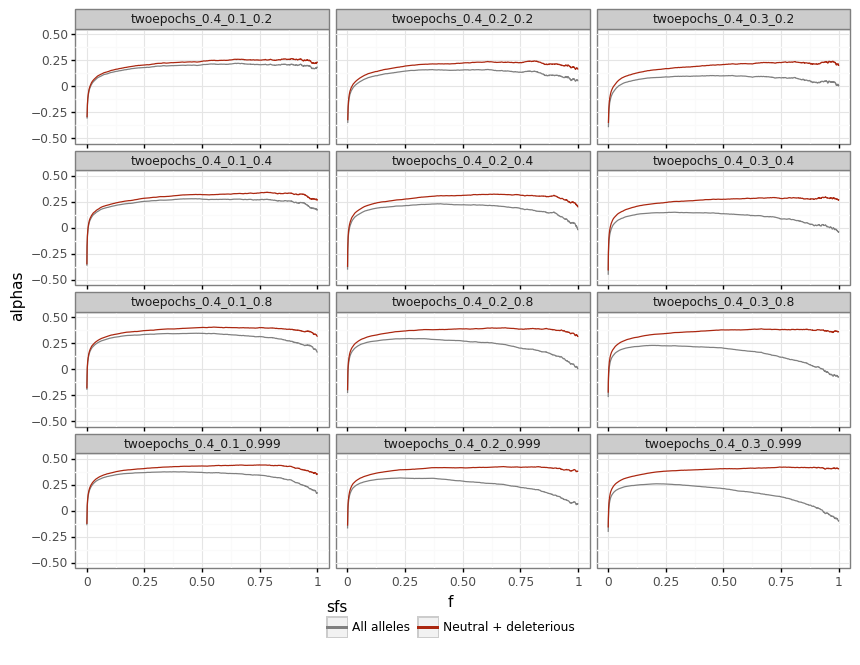

<ggplot: (8776723204009)>

In [10]:
plt.options.figure_size=(10,7)
p = (ggplot(dfAlpha, aes(x='f',y='alphas',color='sfs')) + geom_line() + facet_wrap('~path',ncol=3,scales='free_x') + ylim(-0.5,0.5) + scale_color_manual({'All alleles':'gray',"Neutral + deleterious":'#ab2710'}) + theme_bw() + theme(legend_position='bottom'));p

In [26]:
ggsave(p,filename=PATH + "/results/simulations/slim/isolation/isolationRecaledSimulations.svg")

/home/jmurga/.conda/lib/python3.8/site-packages/plotnine/ggplot.py:727: PlotnineWarning: Saving 10 x 7 in image.
/home/jmurga/.conda/lib/python3.8/site-packages/plotnine/ggplot.py:730: PlotnineWarning: Filename: /home/jmurga/mkt/202004/results/simulations/slim/isolation/isolationRecaledSimulations.svg
/home/jmurga/.conda/lib/python3.8/site-packages/plotnine/facets/facet.py:555: PlotnineWarning: If you need more space for the y-axis tick text use ... + theme(subplots_adjust={'hspace': 0.25}). Choose an appropriate value for 'hspace'
/home/jmurga/.conda/lib/python3.8/site-packages/plotnine/geoms/geom_path.py:75: PlotnineWarning: geom_path: Removed 1 rows containing missing values.


In [7]:
df,dfAlpha = saveSimulatedAlphas(table=simTable,cumulative=False)

In [27]:
dfAlpha['B'] = round(dfAlpha['B'],3)
dfAlpha['group'] = dfAlpha.path + ": " + dfAlpha.sfs
dfAlpha['path']  = pd.Categorical(dfAlpha.path, categories=pd.unique(dfAlpha.path))
plt.options.figure_size=(10,7)
p = (ggplot(dfAlpha, aes(x='f',y='alphas',color='sfs')) + geom_line() + facet_wrap('~path',ncol=3,scales='free_x') + ylim(-0.5,0.5) + scale_color_manual({'All alleles':'gray',"Neutral + deleterious":'#ab2710'}) + theme_bw() + theme(legend_position='bottom'));p

TypeError: unsupported operand type(s) for +: 'Categorical' and 'str'